
Let's see some examples demonstrating that some hypothese are required for the Frobenius-Perron theorem.

We expect that diagrams which are not strongly connected and diagrams which are not acyclic might fail to satisfy the conclusion of Frobenius-Perron.

# acyclic 
Consider a *cycle*

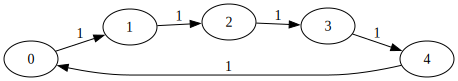

In [1]:
import numpy as np
import numpy.linalg as npl
from graphviz import Digraph 

def cycle(n=5,labels=None):
    if labels==None:
        labels= n*[1]
    cyc = Digraph()
    cyc.attr(rankdir='LR')
    I = list(range(n))

    for i in I:
        cyc.node(f"{i}")

    for i in I:
        cyc.edge(f"{i}",f"{np.mod(i+1,n)}",f"{labels[i]}")

    return cyc
    
cycle()

What is the corresponding matrix $P$?

Well, we can represent the a graph by a dictionary whose keys are pairs `(a,b)` and whose value is the probability of the corresponding state transition.

In [4]:
cd = { (n,(n+1) % 5):1 for n in range(5) }
cd

{(0, 1): 1, (1, 2): 1, (2, 3): 1, (3, 4): 1, (4, 0): 1}

In [7]:

def mat(dict):
    return np.array([[1 if (i,j) in dict else 0 
                      for j in range(5)] 
                     for i in range(5)])

M=mat(cd)
M

array([[0, 1, 0, 0, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 0, 0, 1],
       [1, 0, 0, 0, 0]])

In [8]:
import numpy.linalg as npl
e_vals, e_vects = npl.eig(M)
e_vals

array([-0.80901699+0.58778525j, -0.80901699-0.58778525j,
        0.30901699+0.95105652j,  0.30901699-0.95105652j,
        1.        +0.j        ])

Notice that every eigenvalue of the matrix `M` is 0. In particular, the conclusion of the *Frobenius-Perron Theorem* does not hold for `M`.

Adding an extra edge `4 -> 4` fixes the problem!

In [3]:
acd = { (n,(n+1) % 5):1 for n in range(5) }
acd[(4,4)] = .5
acd[(4,0)]= .5
acd

{(0, 1): 1, (1, 2): 1, (2, 3): 1, (3, 4): 1, (4, 0): 0.5, (4, 4): 0.5}

In [9]:
Ma=mat(acd)
Ma

array([[0. , 1. , 0. , 0. , 0. ],
       [0. , 0. , 1. , 0. , 0. ],
       [0. , 0. , 0. , 1. , 0. ],
       [0. , 0. , 0. , 0. , 1. ],
       [0.5, 0. , 0. , 0. , 0.5]])

In [12]:
ae_vals,ae_vecs = npl.eig(Ma)
ae_vals

array([ 1.        +0.j        ,  0.37103484+0.80377194j,
        0.37103484-0.80377194j, -0.62103484+0.50229651j,
       -0.62103484-0.50229651j])

In [14]:
[ float(abs(x)) for x in ae_vals ]

[0.9999999999999989,
 0.8852774620837582,
 0.8852774620837582,
 0.7987402949603679,
 0.7987402949603679]

# Failure of "strongly connected" condition

Here is a diagram with 3 nodes which is not strongly connected.

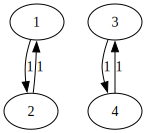

In [28]:

from itertools import product

h = Digraph()

h.edge("1","2","1")
h.edge("2","1","1")
h.edge("3","4","1")
h.edge("4","3","1")
h

The transition matrix is given by:

In [29]:
B =np.array([[0,1,0,0],
             [1,0,0,0],
             [0,0,0,1],
             [0,0,1,0]])

B

array([[0, 1, 0, 0],
       [1, 0, 0, 0],
       [0, 0, 0, 1],
       [0, 0, 1, 0]])

In [30]:
b_evals, be_vecs = np.linalg.eig(B)

b_evals

array([ 1., -1.,  1., -1.])

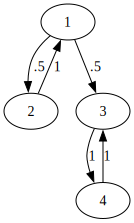

In [32]:

from itertools import product

hh = Digraph()

hh.edge("1","2",".5")
hh.edge("2","1","1")
hh.edge("3","4","1")
hh.edge("4","3","1")
hh.edge("1","3",".5")

hh

In [34]:
BB =np.array([[0,1,0,0],
             [.5,0,0,0],
             [.5,0,0,1],
             [0,0,1,0]])

BB


array([[0. , 1. , 0. , 0. ],
       [0.5, 0. , 0. , 0. ],
       [0.5, 0. , 0. , 1. ],
       [0. , 0. , 1. , 0. ]])

In [36]:
bb_evals, bbe_vecs = np.linalg.eig(BB)

bb_evals

array([-1.        , -0.70710678,  1.        ,  0.70710678])